# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)**
> Success is reading the student's ID card on the first tap:
> - $p = 0.92$
> - $P(X=1) = p = 0.92$
> - $P(X=0) = 1 - p = 1 - 0.92 = 0.08$
>
> **(b)**
> - **Mean:** $E[X] = p = 0.92$
> - **Variance:** $Var(X) = p(1 - p) = 0.92 \times (1 - 0.92) = 0.92 \times 0.08 = 0.0736$

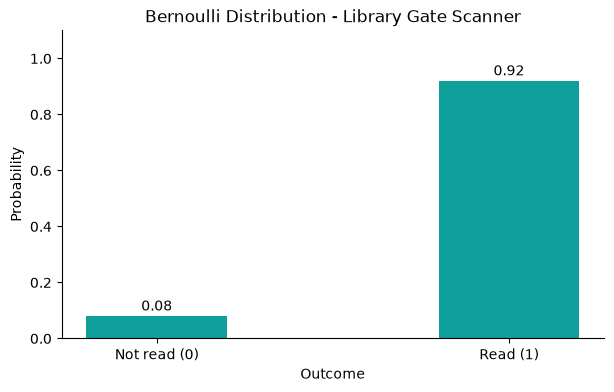

Scipy Mean: 0.92
Scipy Variance: 0.0736


In [2]:
p = 0.92
x = [0, 1]

# calculate PMF
pmf = stats.bernoulli.pmf(x, p)

# plot bar chart
bars = plt.bar(x, pmf, color=DISCRETE_COLOR, width=0.4)
plt.xticks(x, ["Not read (0)", "Read (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution - Library Gate Scanner")

# write probability value on top of each bar
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}", ha="center")

plt.ylim(0, 1.1)
plt.show()

# mean and variance from scipy
mean_val = stats.bernoulli.mean(p)
var_val = stats.bernoulli.var(p)

print("Scipy Mean:", mean_val)
print("Scipy Variance:", round(var_val, 4))

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)**
> Estimated success probability $\hat{p}$:
> $$\hat{p} = \frac{1740}{2000} = 0.87$$
> Full PMF:
> $$P(X = x) = (0.87)^x (1 - 0.87)^{1-x} = (0.87)^x (0.13)^{1-x}, \quad \text{for } x \in \{0, 1\}$$
> That is, $P(X=1) = 0.87$ and $P(X=0) = 0.13$.
>
> **(b)**
> - **Mean:** $E[X] = p = 0.87$
> - **Variance:** $Var(X) = p(1 - p) = 0.87 \times 0.13 = 0.1131$
>
> **Largest possible variance:**
> We have $Var(X) = p(1 - p) = p - p^2$.
> Taking the first derivative with respect to $p$ and setting to zero:
> $$\frac{d}{dp}[p - p^2] = 1 - 2p = 0 \implies p = 0.5$$
> The second derivative is $\frac{d^2}{dp^2} = -2 < 0$, confirming a maximum.
> The largest possible variance is:
> $$Var(X)_{\max} = 0.5 \times (1 - 0.5) = 0.25$$

Theoretical p: 0.8700
Simulated proportion: 0.8675


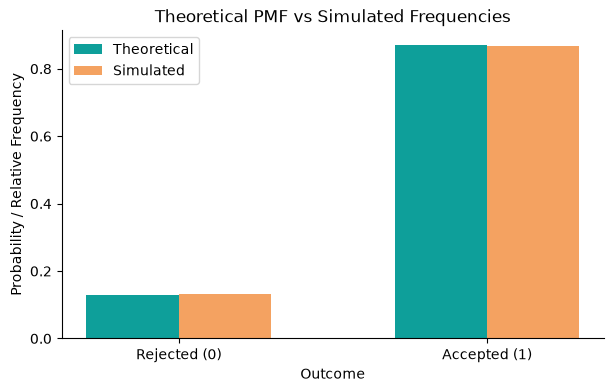

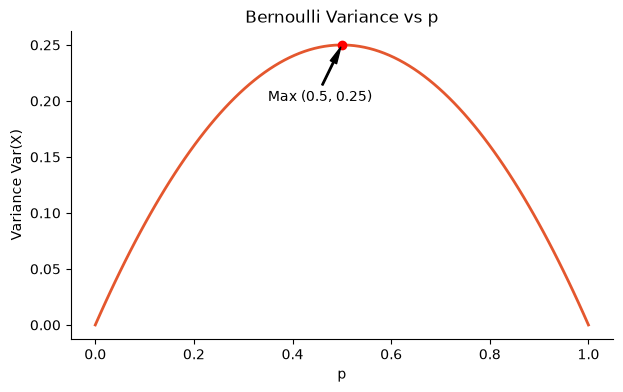

In [3]:
# estimate p from attendance data
p = 1740 / 2000
n_sim = 2000

# simulate 2000 Bernoulli trials
sim_data = stats.bernoulli.rvs(p, size=n_sim, random_state=42)
sim_p = np.mean(sim_data)

print(f"Theoretical p: {p:.4f}")
print(f"Simulated proportion: {sim_p:.4f}")

# plot theoretical PMF vs simulated relative frequencies side by side
x = np.array([0, 1])
width = 0.3
theo_pmf = [1 - p, p]
sim_pmf = [1 - sim_p, sim_p]

plt.bar(x - width/2, theo_pmf, width=width, label="Theoretical", color=DISCRETE_COLOR)
plt.bar(x + width/2, sim_pmf, width=width, label="Simulated", color=HIGHLIGHT_COLOR)
plt.xticks(x, ["Rejected (0)", "Accepted (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability / Relative Frequency")
plt.title("Theoretical PMF vs Simulated Frequencies")
plt.legend()
plt.show()

# plot Var(X) = p(1-p) vs p in second figure
p_vals = np.linspace(0, 1, 100)
var_vals = p_vals * (1 - p_vals)

plt.figure()
plt.plot(p_vals, var_vals, color=CONTINUOUS_COLOR, lw=2)
plt.plot(0.5, 0.25, marker="o", color="red")
plt.annotate("Max (0.5, 0.25)", xy=(0.5, 0.25), xytext=(0.35, 0.20),
             arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5))
plt.xlabel("p")
plt.ylabel("Variance Var(X)")
plt.title("Bernoulli Variance vs p")
plt.show()

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)**
> - $n = 12$
> - $p = \frac{1}{4} = 0.25$
>
> **BINS conditions check:**
> - **B**inary: Each question is either correct ($X=1$) or incorrect ($X=0$).
> - **I**ndependent: Guessing on one question does not affect other questions.
> - **N**umber of trials is fixed: $n = 12$.
> - **S**ame probability of success: $p = 0.25$ for each question.
>
> Computing $\binom{12}{5}$:
> $$\binom{12}{5} = \frac{12 \times 11 \times 10 \times 9 \times 8}{5 \times 4 \times 3 \times 2 \times 1} = \frac{95040}{120} = 792$$
>
> Computing $P(X = 5)$ by hand:
> $$P(X = 5) = \binom{12}{5} p^5 (1 - p)^{12-5} = 792 \times (0.25)^5 \times (0.75)^7$$
> $$= 792 \times 0.0009765625 \times 0.13348389 \approx 0.1032$$
>
> **(b)**
> - **Mean:** $E[X] = np = 12 \times 0.25 = 3$
> - **Variance:** $Var(X) = np(1 - p) = 12 \times 0.25 \times 0.75 = 2.25$

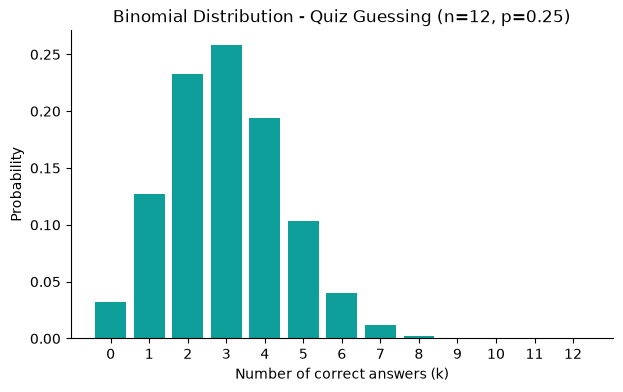

P(X = 5): 0.1032
Mean: 3.0
Variance: 2.25


In [4]:
n = 12
p = 0.25
k = np.arange(0, n + 1)

# calculate PMF
pmf = stats.binom.pmf(k, n, p)

# plot PMF
plt.bar(k, pmf, color=DISCRETE_COLOR)
plt.xlabel("Number of correct answers (k)")
plt.ylabel("Probability")
plt.title("Binomial Distribution - Quiz Guessing (n=12, p=0.25)")
plt.xticks(k)
plt.show()

print("P(X = 5):", round(stats.binom.pmf(5, n, p), 4))
print("Mean:", stats.binom.mean(n, p))
print("Variance:", stats.binom.var(n, p))

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> *(Note: Question 4 was omitted in the assignment notebook template)*

---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)**
> Here $\lambda = 3$ and $e^{-3} \approx 0.0498$.
> Formula: $P(X = k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$
>
> - For $k = 0$:
>   $$P(X = 0) = \frac{3^0 e^{-3}}{0!} = \frac{1 \times 0.0498}{1} = 0.0498$$
>
> - For $k = 2$:
>   $$P(X = 2) = \frac{3^2 e^{-3}}{2!} = \frac{9 \times 0.0498}{2} = \frac{0.4482}{2} = 0.2241$$
>
> **(b)**
> - **Mean:** $E[X] = \lambda = 3$
> - **Variance:** $Var(X) = \lambda = 3$
> - **Special property:** For a Poisson distribution, the **mean equals the variance** ($E[X] = Var(X) = \lambda$).

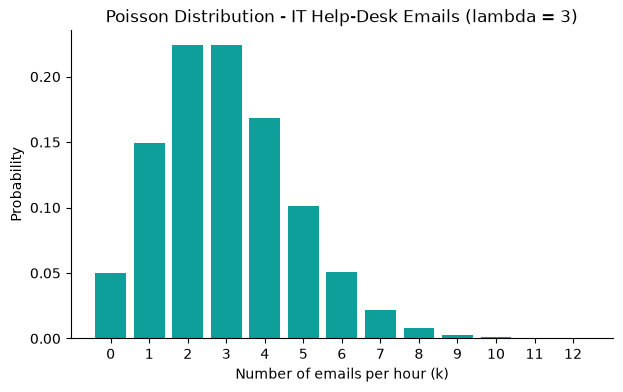

P(X = 0): 0.0498
P(X = 2): 0.224
P(X <= 5): 0.9161
Smallest k for P(X <= k) >= 0.95: 6


In [5]:
la = 3
k = np.arange(0, 13)

# calculate PMF
pmf = stats.poisson.pmf(k, la)

# plot PMF
plt.bar(k, pmf, color=DISCRETE_COLOR)
plt.xlabel("Number of emails per hour (k)")
plt.ylabel("Probability")
plt.title("Poisson Distribution - IT Help-Desk Emails (lambda = 3)")
plt.xticks(k)
plt.show()

# probabilities
print("P(X = 0):", round(stats.poisson.pmf(0, la), 4))
print("P(X = 2):", round(stats.poisson.pmf(2, la), 4))
print("P(X <= 5):", round(stats.poisson.cdf(5, la), 4))

# smallest k where P(X <= k) >= 0.95
k_95 = int(stats.poisson.ppf(0.95, la))
print(f"Smallest k for P(X <= k) >= 0.95: {k_95}")

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> **(a)**
> - Hourly rate: $\lambda_1 = 1.5$ errors/hour
> - Rate for 8-hour shift: $\lambda = 1.5 \times 8 = 12$
>
> Probability of a clean shift ($X = 0$):
> $$P(X = 0) = \frac{12^0 e^{-12}}{0!} = e^{-12} \approx 6.1442 \times 10^{-6} \approx 0.00000614$$
>
> **(b)**
> - **Mean:** $E[X] = \lambda = 12$
> - **Variance:** $Var(X) = \lambda = 12$
>
> Expression for engineer paged ($X > 18$):
> $$P(X > 18) = 1 - P(X \le 18) = \sum_{k=19}^{\infty} \frac{12^k e^{-12}}{k!}$$
> In `scipy.stats`, the function that gives it directly is `stats.poisson.sf(18, 12)` (the survival function).

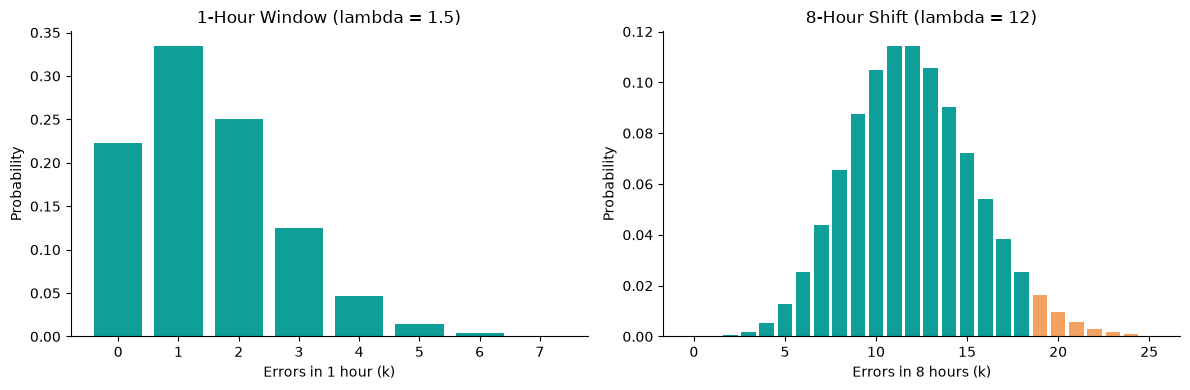

P(Clean shift, X = 0 in 8 hrs): 6.14421235332821e-06
P(Engineer paged, X > 18): 0.0374


In [6]:
la_1 = 1.5
la_8 = 12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1-hour window
k1 = np.arange(0, 8)
pmf1 = stats.poisson.pmf(k1, la_1)
ax1.bar(k1, pmf1, color=DISCRETE_COLOR)
ax1.set_xlabel("Errors in 1 hour (k)")
ax1.set_ylabel("Probability")
ax1.set_title("1-Hour Window (lambda = 1.5)")

# 8-hour window
k8 = np.arange(0, 26)
pmf8 = stats.poisson.pmf(k8, la_8)
colors = [HIGHLIGHT_COLOR if i > 18 else DISCRETE_COLOR for i in k8]
ax2.bar(k8, pmf8, color=colors)
ax2.set_xlabel("Errors in 8 hours (k)")
ax2.set_ylabel("Probability")
ax2.set_title("8-Hour Shift (lambda = 12)")

plt.tight_layout()
plt.show()

# probabilities
p_clean = stats.poisson.pmf(0, la_8)
p_paged = stats.poisson.sf(18, la_8)

print("P(Clean shift, X = 0 in 8 hrs):", p_clean)
print("P(Engineer paged, X > 18):", round(p_paged, 4))

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)**
> Given $\mu = 18$ hours, $\sigma = 1.5$ hours, $x = 15$ hours.
> $$Z = \frac{X - \mu}{\sigma} = \frac{15 - 18}{1.5} = \frac{-3}{1.5} = -2.0$$
> **Meaning:** A battery life of 15 hours is exactly 2 standard deviations below the mean battery life.
>
> **(b)**
> According to the 68–95–99.7 empirical rule, approximately **95%** of phone battery lives lie within $\mu \pm 2\sigma$:
> - Lower limit: $\mu - 2\sigma = 18 - 2(1.5) = 18 - 3 = 15$ hours
> - Upper limit: $\mu + 2\sigma = 18 + 2(1.5) = 18 + 3 = 21$ hours
>
> Therefore, approximately 95% of the phones have battery lives in the interval **$[15, 21]$ hours**.

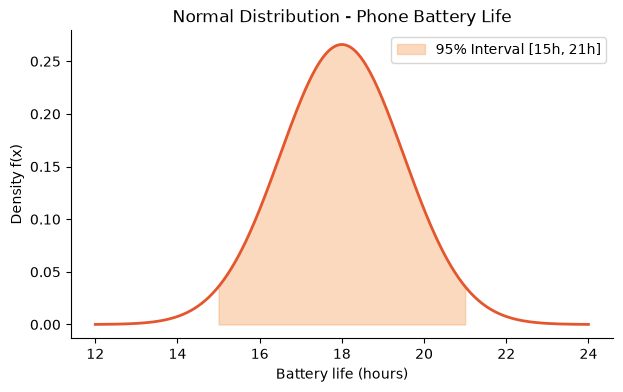

Z-score for 15 hours: -2.0


In [7]:
mu = 18
sigma = 1.5

# generate x values over mu +- 4*sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, mu, sigma)

# plot curve
plt.plot(x, pdf, color=CONTINUOUS_COLOR, lw=2)

# shade 95% interval (mu +- 2*sigma)
x_int = np.linspace(mu - 2*sigma, mu + 2*sigma, 200)
pdf_int = stats.norm.pdf(x_int, mu, sigma)
plt.fill_between(x_int, pdf_int, color=HIGHLIGHT_COLOR, alpha=0.4, label="95% Interval [15h, 21h]")

plt.xlabel("Battery life (hours)")
plt.ylabel("Density f(x)")
plt.title("Normal Distribution - Phone Battery Life")
plt.legend()
plt.show()

# Z-score for 15 hours
z_15 = (15 - mu) / sigma
print("Z-score for 15 hours:", z_15)

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> **(a)**
> Given: $\mu = 200$ ml. Overflow occurs when fill exceeds $210$ ml, which happens for 2.5% of cups:
> $$P(X > 210) = 0.025 \implies P(X \le 210) = 0.975$$
> Using the standard normal value $z_{0.975} \approx 1.96$:
> $$Z = \frac{X - \mu}{\sigma} \implies 1.96 = \frac{210 - 200}{\sigma} = \frac{10}{\sigma}$$
> $$\sigma = \frac{10}{1.96} \approx 5.1020\text{ ml}$$
>
> **(b)**
> - **1st percentile volume ($P(X \le x) = 0.01$):**
>   In `scipy`, this is given by `stats.norm.ppf(0.01, loc=200, scale=sigma)`.
>   Using $z_{0.01} \approx -2.3263$:
>   $$x = \mu + z_{0.01}\sigma = 200 + (-2.3263 \times 5.1020) \approx 188.13\text{ ml}$$
>
> - **Customer complaint probability ($X < 190$ ml):**
>   $$P(X < 190) = P\left(Z < \frac{190 - 200}{5.1020}\right) = P(Z < -1.96) \approx 0.0250$$

Computed sigma: 5.1021 ml


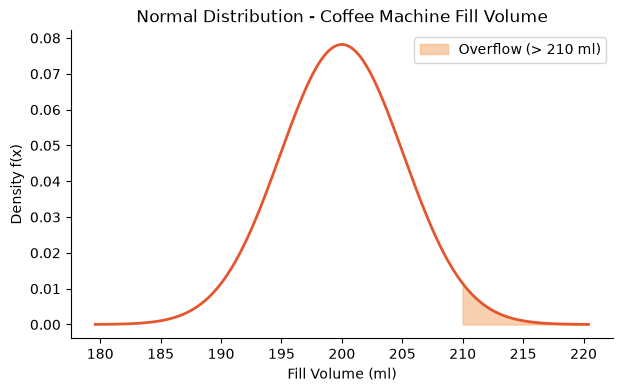

1st percentile volume: 188.13 ml
P(X < 190 ml): 0.0250


In [8]:
mu = 200

# compute sigma using stats.norm.ppf
z = stats.norm.ppf(0.975)
sigma = (210 - mu) / z
print(f"Computed sigma: {sigma:.4f} ml")

# generate x values
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, mu, sigma)

# plot curve
plt.plot(x, pdf, color=CONTINUOUS_COLOR, lw=2)

# shade overflow (> 210 ml)
x_over = np.linspace(210, mu + 4*sigma, 100)
plt.fill_between(x_over, stats.norm.pdf(x_over, mu, sigma), 
                 color=HIGHLIGHT_COLOR, alpha=0.5, label="Overflow (> 210 ml)")

plt.xlabel("Fill Volume (ml)")
plt.ylabel("Density f(x)")
plt.title("Normal Distribution - Coffee Machine Fill Volume")
plt.legend()
plt.show()

# 1st percentile and P(X < 190 ml)
val_1st = stats.norm.ppf(0.01, loc=mu, scale=sigma)
p_under = stats.norm.cdf(190, loc=mu, scale=sigma)

print(f"1st percentile volume: {val_1st:.2f} ml")
print(f"P(X < 190 ml): {p_under:.4f}")

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)**
> For a continuous Uniform distribution on $[a, b] = [0, 15]$:
> - **Mean:**
>   $$E[X] = \frac{a + b}{2} = \frac{0 + 15}{2} = 7.5\text{ minutes}$$
>
> - **Variance:**
>   $$Var(X) = \frac{(b - a)^2}{12} = \frac{(15 - 0)^2}{12} = \frac{225}{12} = 18.75\text{ minutes}^2$$
>
> - Standard deviation $\sigma = \sqrt{18.75} \approx 4.3301$ minutes.

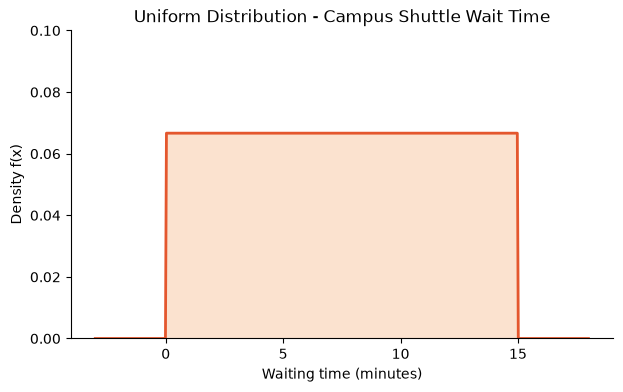

Mean waiting time: 7.50 minutes
Variance: 18.75 minutes^2


In [9]:
a = 0
b = 15

# generate x values extending beyond [0, 15]
x = np.linspace(-3, 18, 500)
pdf = stats.uniform.pdf(x, loc=a, scale=b - a)

# plot PDF
plt.plot(x, pdf, color=CONTINUOUS_COLOR, lw=2)
plt.fill_between(x, pdf, color=HIGHLIGHT_COLOR, alpha=0.3)
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Density f(x)")
plt.title("Uniform Distribution - Campus Shuttle Wait Time")
plt.ylim(0, 0.1)
plt.show()

# mean and variance
mean_val = stats.uniform.mean(loc=a, scale=b - a)
var_val = stats.uniform.var(loc=a, scale=b - a)

print(f"Mean waiting time: {mean_val:.2f} minutes")
print(f"Variance: {var_val:.2f} minutes^2")